In [20]:
from boututils.datafile import DataFile
from boutdata.collect import collect
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os, sys, pathlib
import platform
import traceback
import xarray as xr
import xbout
from pathlib import Path
import xhermes as xh

sys.path.append(os.path.join(r"/users/jlb647/scratch/simulation_program/hermes-3_sim/sdtool_load_test/sdtools"))
sys.path.append(os.path.join(r"/users/jlb647/scratch/simulation_program/hermes-3_sim/analysis/my_notebooks/notebooks/hermes-3/transients"))
sys.path.append(os.path.join(r"/users/jlb647/scratch/simulation_program/hermes-3_sim/analysis/my_notebooks/notebooks/hermes-3/general_functions"))


from plotting_functions import *
from convergence_functions import * 

from hermes3.case_db import *
from hermes3.casedeck import*
from hermes3.load import *
from hermes3.named_selections import *
from hermes3.plotting import *
from hermes3.grid_fields import *
from hermes3.accessors import *
from hermes3.utils import *
from hermes3.fluxes import *
from hermes3.selectors import *
from hermes3.front_tracking import *
# from hermes3.balance1d import *

# plt.style.use('ggplot')
plt.rcParams.update({'font.size': 10})
linewidth = 3
markersize = 15



# plt.style.use('ggplot')
plt.style.use('default')
plt.rcParams["axes.edgecolor"] = "black"
plt.rcParams["axes.linewidth"] = 1
plt.rcParams['xtick.labelsize'] = 18
plt.rcParams['ytick.labelsize'] = 18
plt.rcParams['axes.grid'] = True
plt.rcParams.update({'font.size': 16})



%load_ext autoreload
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# I/O

In [21]:

to_load = ['/users/jlb647/scratch/simulation_program/hermes-3_sim/simulation_dir/2024-11_week11_production/power_pulse/300%_fluence/power_and_density/FL/case_01',
           '/users/jlb647/scratch/simulation_program/hermes-3_sim/simulation_dir/2024-11_week11_production/power_pulse/300%_fluence/power_only/FL/case_01'
            ]

names = ['power_and_density', 'power_only']

cs = dict()

for index,i in enumerate(to_load):
    i = Path(i)
    name = f"{names[index]}"
    print(f"Loading {name}")
    cs[name] = Load.case_1D(i, guard_replace = False, use_squash=True)

print(cs.keys())

Loading power_and_density
- Looking for squash file
- Squash file found. squash date 04/23/2025, 20:04:43, dmp file date 11/26/2024, 06:50:17
Skipping unnormalisation
Loading power_only
- Looking for squash file
- Squash file found. squash date 04/16/2025, 17:07:20, dmp file date 11/26/2024, 05:57:59
Skipping unnormalisation
dict_keys(['power_and_density', 'power_only'])


In [22]:
print(cs['power_and_density'].ds.data_vars)

Data variables:
    Bxy                      (pos) float64 dask.array<chunksize=(404,), meta=np.ndarray>
    Ed+_iz                   (t, pos) float64 dask.array<chunksize=(3001, 404), meta=np.ndarray>
    Ed+_rec                  (t, pos) float64 dask.array<chunksize=(3001, 404), meta=np.ndarray>
    Ed+_sheath               (t, pos) float64 dask.array<chunksize=(3001, 404), meta=np.ndarray>
    Ed_target_recycle        (t, pos) float64 dask.array<chunksize=(3001, 404), meta=np.ndarray>
    Edd+_cx                  (t, pos) float64 dask.array<chunksize=(3001, 404), meta=np.ndarray>
    Ee_sheath                (t, pos) float64 dask.array<chunksize=(3001, 404), meta=np.ndarray>
    EnergyFlow_d+_ylow       (t, pos) float64 dask.array<chunksize=(3001, 404), meta=np.ndarray>
    EnergyFlow_e_ylow        (t, pos) float64 dask.array<chunksize=(3001, 404), meta=np.ndarray>
    Fd+_iz                   (t, pos) float64 dask.array<chunksize=(3001, 404), meta=np.ndarray>
    Fd+_rec           

In [23]:
def detachment_front_index(ds, time=None):
    """
    Function to find the location of the detachment in the simulation
    """
    if time == None:
        ds = ds.isel(t=-1)

    else:
        ds = ds.isel(t=time)

    # Get the detachment location
    try:
        detachment_idx = np.where(ds['Te'][2:-2] < 5)[0][0]
    except:
        # If the detachment index is not found, return None
        print("No detachment found")
        detachment_idx = 0

    return detachment_idx


# Density during pulse

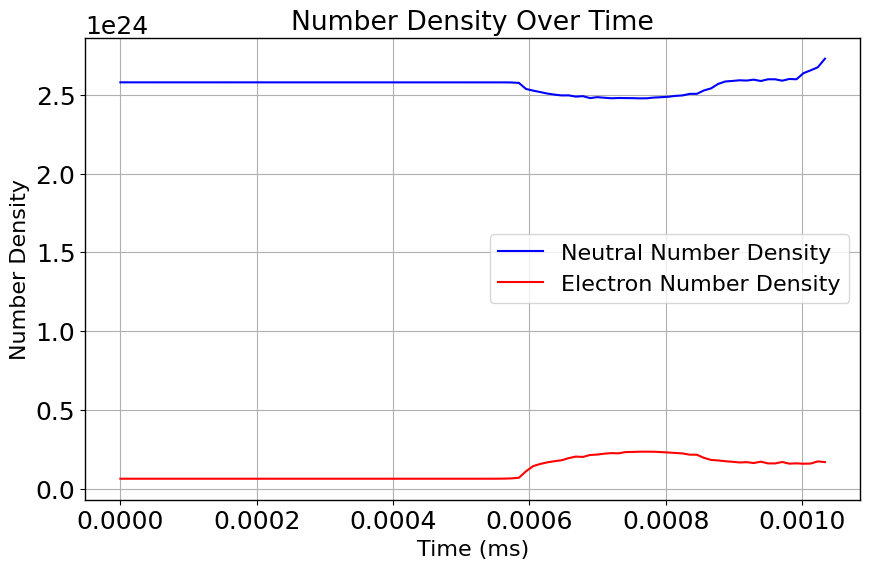

In [24]:
# Load 0–80 time steps
ds = cs['power_and_density'].ds.isel(t=slice(0, 100))

# Multiply Nd and dv over the spatial slice
Nd_tot = ds['Nd'].isel(pos=slice(2, -2)) * ds['dv'].isel(pos=slice(2, -2))
Ne_tot = ds['Ne'].isel(pos=slice(2, -2)) * ds['dv'].isel(pos=slice(2, -2))

# Sum over 'pos' to get one value per time step
neutral_num_time_series = Nd_tot.sum(dim='pos')
electron_num_time_series = Ne_tot.sum(dim='pos')

import matplotlib.pyplot as plt

# Optional: convert to numpy for plotting
time = ds['t'].values - ds['t'].values[0]  # Adjust time to start from 0
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(time, neutral_num_time_series, label='Neutral Number Density', color='blue')
ax.plot(time, electron_num_time_series, label='Electron Number Density', color='red')
ax.set_xlabel('Time (ms)')
ax.set_ylabel('Number Density')
ax.set_title('Number Density Over Time')
ax.legend()

def spatial_sum(ds, var):
    """
    Function to sum over the spatial dimension of a variable
    """
    # Multiply Nd and dv over the spatial slice
    Nd_tot = ds[var].isel(pos=slice(2, -2)) * ds['dv'].isel(pos=slice(2, -2))

    # Sum over 'pos' to get one value per time step
    return Nd_tot.sum(dim='pos')


def plot_spatial_sum_time_series(cs, var, time_range = None):
    """
    Function to plot the spatial sum of a variable over time
    """
    # Optional: convert to numpy for plotting
    ds = cs.ds
    if time_range is not None:
        ds = ds.isel(t=slice(time_range))
    else:
        ds = ds.isel(t=slice(0, -1))

    time = ds['t'].values - ds['t'].values[0]  # Adjust time to start from 0
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.plot(time, spatial_sum(ds, var), label=f'{var}')
    ax.set_xlabel('Time (ms)')
    ax.set_ylabel(fr'\sum {var} ({ds[var].units})')
    ax.set_title(f'Spatial Sum of {var} Over Time')
    ax.legend()


In [25]:
def spatial_sum(ds, var, mult_dv=True, spatial_dim='pos', spatial_slice=slice(2, -2)):
    """
    Function to sum over the spatial dimension of a variable.

    Parameters:
    - ds: xarray.Dataset
    - var: variable name as a string
    - mult_dv: whether to multiply by dv
    - spatial_dim: name of spatial dimension
    - spatial_slice: slice of the spatial dimension to include

    Returns:
    - xarray.DataArray of summed values over time
    """
    if mult_dv:
        tot = ds[var].isel({spatial_dim: spatial_slice}) * ds['dv'].isel({spatial_dim: spatial_slice})
    else:
        tot = ds[var].isel({spatial_dim: spatial_slice})

    return tot.sum(dim=spatial_dim)



def plot_spatial_sum_time_series(cs, vars, mult_dv=True, time_range=None,
                                  spatial_dim='pos', y_scale=None, abs = False,plot_src = False):
    """
    Function to plot the spatial sum of one or more variables over time.

    Parameters:
    - cs: container with .ds (xarray.Dataset)
    - vars: list of variable names (strings)
    - mult_dv: whether to multiply by dv before summing
    - time_range: tuple (start, end) for time slicing
    - spatial_dim: spatial dimension to sum over
    """
    import matplotlib.pyplot as plt

    ds = cs.ds
    if time_range is not None:
        ds = ds.isel(t=slice(*time_range))
    else:
        ds = ds.isel(t=slice(0, -1))

    time = (ds['t'].values - ds['t'].values[0]) *1e3  # normalize time to start at 0

    fig, ax = plt.subplots(figsize=(12, 8))
    for var in vars:
        if abs:
            summed = np.abs(spatial_sum(ds, var, mult_dv=mult_dv, spatial_dim=spatial_dim))
        else:
            summed = spatial_sum(ds, var, mult_dv=mult_dv, spatial_dim=spatial_dim)
        ax.plot(time, summed, label=f'{var} ({ds[var].units})', linewidth=linewidth, markersize=markersize)


    if plot_src:
        ax2 = ax.twinx()
        summed_src = spatial_sum(ds, 'Pe_src', mult_dv=False, spatial_dim=spatial_dim)
        ax2.plot(time, summed_src, label='Pe_src', color='black', linewidth=linewidth, markersize=markersize)
    ax.set_xlabel('Time (ms)')
    if mult_dv:
        ax.set_ylabel(fr'Spatial Sum ($\sum$ {vars} $\cdot  dV$)')
    else:
        ax.set_ylabel(fr'Spatial Sum ($\sum$ {vars})')
        
    # ax.set_title('Spatial Sum Over Time')
    if y_scale is not None:
        ax.set_yscale(f'{y_scale}')
    else:
        ax.set_yscale('linear')


    fig.legend(ncols = 2)
    ax.grid(True)
    plt.show()


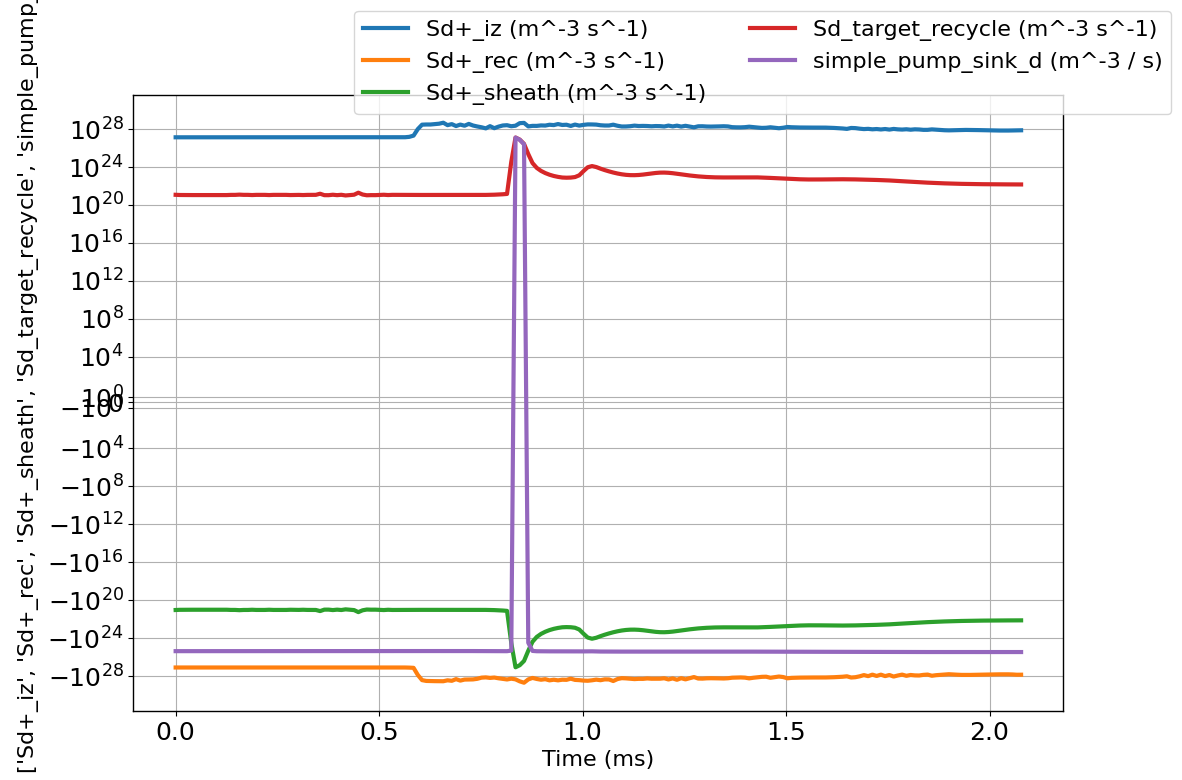

In [26]:

sources_sinks = ['Sd+_iz', 'Sd+_rec','Sd+_sheath','Sd_target_recycle', 'simple_pump_sink_d']

plot_spatial_sum_time_series(cs['power_and_density'], vars = sources_sinks, time_range=(0, 200), mult_dv=True, y_scale='symlog', abs = False)

1.9710000391727428e+28
time taken to ionise neutral cloud =  0.13089102987072135 ms


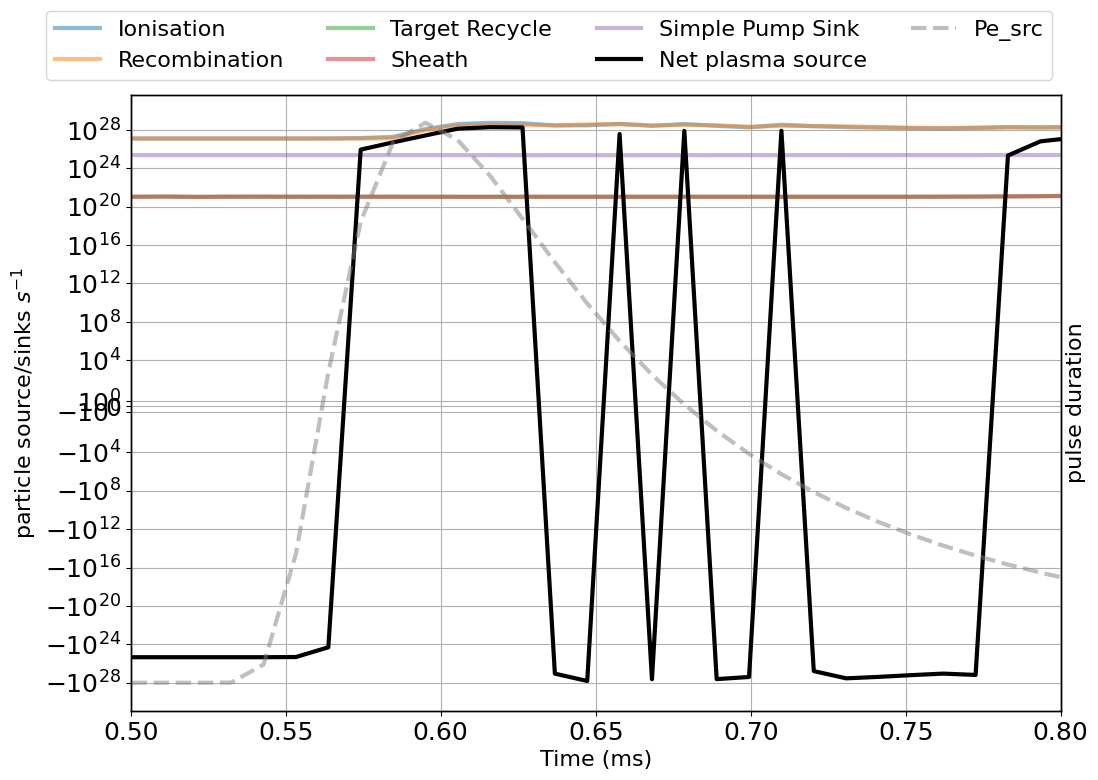

In [27]:
import matplotlib.pyplot as plt

time_range = (0, 500)
ds = cs['power_only'].ds
if time_range is not None:
    ds = ds.isel(t=slice(*time_range))
else:
    ds = ds.isel(t=slice(0, -1))

time = (ds['t'].values - ds['t'].values[0]) *1e3  # normalize time to start at 0

fig, ax = plt.subplots(figsize=(12, 8))
ax2 = ax.twinx()

ionisation = (ds['Sd+_iz'].isel(pos=slice(2, -2)) * ds['dv'].isel(pos=slice(2, -2))).sum(dim='pos')
recombination = (ds['Sd+_rec'].isel(pos=slice(2, -2)) * ds['dv'].isel(pos=slice(2, -2))).sum(dim='pos')
target_recycle = (ds['Sd_target_recycle'].isel(pos=slice(2, -2)) * ds['dv'].isel(pos=slice(2, -2))).sum(dim='pos')
sheath = (ds['Sd+_sheath'].isel(pos=slice(2, -2)) * ds['dv'].isel(pos=slice(2, -2))).sum(dim='pos')
simple_pump_sink_d = (ds['simple_pump_sink_d'].isel(pos=slice(2, -2)) * ds['dv'].isel(pos=slice(2, -2))).sum(dim='pos')
upstream_source_plasma = (ds['Sd+_src'].isel(pos=slice(2, -2)) * ds['dv'].isel(pos=slice(2, -2))).sum(dim='pos')
neutral_source = (ds['Sd_src'].isel(pos=slice(2, -2)) * ds['dv'].isel(pos=slice(2, -2))).sum(dim='pos')

# Calculate the net ionisation
net_ionisation = ionisation + recombination + target_recycle + sheath + simple_pump_sink_d

ax.plot(time, ionisation, label='Ionisation', linewidth=linewidth, markersize=markersize, alpha=0.5)
ax.plot(time, -1*recombination, label='Recombination', linewidth=linewidth, markersize=markersize, alpha=0.5)
ax.plot(time, target_recycle, label='Target Recycle', linewidth=linewidth, markersize=markersize, alpha=0.5)
ax.plot(time, -1*sheath, label='Sheath', linewidth=linewidth, markersize=markersize, alpha=0.5)
ax.plot(time, -1*simple_pump_sink_d, label='Simple Pump Sink', linewidth=linewidth, markersize=markersize, alpha=0.5)
# Plot the net ionisation
ax.plot(time, net_ionisation, label='Net plasma source', linewidth=linewidth, markersize=markersize, linestyle='-', color='black')
ax2.plot(time, ds['Pe_src'].isel(pos=slice(2, -2)).sum(dim='pos') - ds['Pe_src'].isel(pos=slice(2, -2)).sum(dim='pos')[3], label='Pe_src', color='grey', linewidth=linewidth, markersize=markersize, alpha=0.5, linestyle='--')

ax.set_yscale('symlog') 
ax.set_xlabel('Time (ms)')
ax.set_ylabel(r'particle source/sinks $s^{-1}$')
ax2.grid(False)
ax2.set_ylabel(r'pulse duration')
ax2.set_yticks([])
ax.set_xbound(0.5, 0.8)
fig.legend(ncols=4, loc='upper center')

print(np.max(net_ionisation.values))

print('time taken to ionise neutral cloud = ',  (2.579862250025524e+24 / np.max(net_ionisation.values))*1e3, 'ms')
    

# Burnthrough movie

In [ ]:
import os
import matplotlib.pyplot as plt
import imageio.v2 as imageio
import numpy as np
from PIL import Image

def single_profile_plot(ds_in, time, x_log_scale=True, title='None', save=False, save_path=None, focus_target=False):
    fig, ax = plt.subplots(1, 1, figsize=(12, 8), dpi=300)
    linewidth = 2
    ds = ds_in.ds.copy().isel(t=time)

    ax2 = ax.twinx()

    y = ds['y'][1:-1].values
    y_flipped = (y.max() - y) 

    ax2.plot(y, replace_guards(ds['Te']), color='blue', label='Te', linewidth=linewidth)
    ax2.plot(y, replace_guards(ds['Td+']), color='red', label='Td+', linewidth=linewidth)

    ax.plot(y, replace_guards(ds['Ne']), color='blue', label='Ne', linewidth=linewidth, linestyle='--')
    ax.plot(y, replace_guards(ds['Nd']), color='black', label='Nd', linewidth=linewidth, linestyle=':')

    if x_log_scale:
        ax.set_xscale('log')
    else: 
        ax.set_xscale('linear')



    ax.set_yscale('log')

    ax.set_xlabel('Distance to target (m)', fontsize=20)
    ax.set_ylabel(r'Ne,Nd (m$^{-3}$)', fontsize=20)
    ax2.set_ylabel('T (eV)', fontsize=20)
    ax2.set_ylim(0, 8000)
    ax.set_ylim(1e18, 1e25)
    ax2.grid(False)
    fig.legend(ncol=4, loc='upper right')
    fig.suptitle(f"{(ds_in.ds['t'].values[time] - ds_in.ds['t'].values[0]) * 1e3 : 6f} ms \n time_index = {time}",
                 fontsize=20, x=0.0, horizontalalignment='left')
    if focus_target:
        ax.set_xlim(75, 83)
        ax.set_ylim(1e18, 1e25)
        ax2.set_ylim(0, 10)

    if save:
        plt.savefig(save_path, bbox_inches='tight')
    plt.close()

def make_profile_evolution_video(ds_in, start_time, end_time, fps=5, mp4_filename="profile_evolution.mp4", x_log_scale = True, focus_target=False):
    output_dir = "./frames"
    os.makedirs(output_dir, exist_ok=True)

    # Generate frame plots
    frame_paths = []
    for t in range(start_time, end_time):
        frame_path = os.path.join(output_dir, f"frame_{t:03d}.png")
        single_profile_plot(ds_in, time=t, save=True, save_path=frame_path, x_log_scale=x_log_scale, focus_target=focus_target)
        frame_paths.append(frame_path)

    # Get target frame size
    first_frame = imageio.imread(frame_paths[0])
    target_size = (first_frame.shape[1], first_frame.shape[0])  # width, height

    writer = imageio.get_writer(mp4_filename, fps=fps, codec='libx264', format='ffmpeg')

    for path in frame_paths:
        frame = imageio.imread(path)

        # Resize if necessary
        if (frame.shape[1], frame.shape[0]) != target_size:
            frame = np.array(Image.fromarray(frame).resize(target_size, Image.BICUBIC))

        # Drop alpha if present
        if frame.shape[2] == 4:
            frame = frame[:, :, :3]

        writer.append_data(frame)

    writer.close()


In [58]:
def make_profile_evolution_video_optimized(ds_in, start_time, end_time, fps=5, mp4_filename="profile_evolution.mp4", x_log_scale=True, focus_target=False, interpolation_factor=1):
    """
    Optimized version with frame interpolation for smoother animation
    
    Parameters:
    -----------
    interpolation_factor : int
        Number of interpolated frames between each real data frame
        1 = no interpolation, 2 = 1 extra frame between each real frame, etc.
    """
    # Get time indices and actual time values
    time_indices = list(range(start_time, end_time))
    actual_times = [ds_in.ds['t'].values[t] for t in time_indices]
    
    # Create interpolated time points
    interp_times = []
    interp_indices = []
    
    for i in range(len(time_indices)-1):
        # Add the current time point
        interp_times.append(actual_times[i])
        interp_indices.append(time_indices[i])
        
        # Add interpolated points between current and next
        for j in range(1, interpolation_factor):
            alpha = j / interpolation_factor
            interp_time = actual_times[i] + alpha * (actual_times[i+1] - actual_times[i])
            interp_index = time_indices[i] + alpha * (time_indices[i+1] - time_indices[i])
            interp_times.append(interp_time)
            interp_indices.append(interp_index)
    
    # Add the last frame
    interp_times.append(actual_times[-1])
    interp_indices.append(time_indices[-1])
    
    total_frames = len(interp_times)
    original_frames = len(time_indices)
    print(f"Generating {total_frames} frames ({original_frames} original + {total_frames-original_frames} interpolated)...")
    
    # Create writer
    writer = None
    
    for frame_idx, (interp_time, interp_index) in enumerate(zip(interp_times, interp_indices)):
        if frame_idx % 10 == 0:
            print(f"Processing frame {frame_idx+1}/{total_frames}")
        
        # Determine if this is a real frame or interpolated
        if interp_index in time_indices:
            # Real data frame
            real_idx = int(interp_index)
            ds = ds_in.ds.copy().isel(t=real_idx)
        else:
            # Interpolated frame - blend between adjacent real frames
            lower_idx = int(np.floor(interp_index))
            upper_idx = int(np.ceil(interp_index))
            alpha = interp_index - lower_idx
            
            ds_lower = ds_in.ds.copy().isel(t=lower_idx)
            ds_upper = ds_in.ds.copy().isel(t=upper_idx)
            
            # Create interpolated dataset
            ds = ds_lower.copy()
            for var in ['Te', 'Td+', 'Ne', 'Nd']:
                if var in ds:
                    ds[var] = (1-alpha) * ds_lower[var] + alpha * ds_upper[var]
        
        # Create figure with lower DPI for faster rendering
        fig, ax = plt.subplots(1, 1, figsize=(12, 8), dpi=100)
        linewidth = 2
        ax2 = ax.twinx()

        y = ds['y'][1:-1].values

        ax2.plot(y, replace_guards(ds['Te']), color='blue', label='Te', linewidth=linewidth)
        ax2.plot(y, replace_guards(ds['Td+']), color='red', label='Td+', linewidth=linewidth)
        ax.plot(y, replace_guards(ds['Ne']), color='blue', label='Ne', linewidth=linewidth, linestyle='--')
        ax.plot(y, replace_guards(ds['Nd']), color='black', label='Nd', linewidth=linewidth, linestyle=':')

        if x_log_scale:
            ax.set_xscale('log')
        else: 
            ax.set_xscale('linear')

        ax.set_yscale('log')
        ax.set_xlabel('Distance to target (m)', fontsize=20)
        ax.set_ylabel(r'Ne,Nd (m$^{-3}$)', fontsize=20)
        ax2.set_ylabel('T (eV)', fontsize=20)
        ax2.set_ylim(0, 8000)
        ax.set_ylim(1e18, 1e25)
        ax2.grid(False)
        fig.legend(ncol=4, loc='upper right')
        
        # Calculate relative time from start (works with interpolated times)
        relative_time = (interp_time - actual_times[0]) * 1e3
        relative_index = interp_index - start_time
        
        fig.suptitle(f"{relative_time:.3f} ms \n time_index = {relative_index:.1f}",
                     fontsize=20, x=0.0, horizontalalignment='left')
        
        if focus_target:
            ax.set_xlim(75, 83)
            ax.set_ylim(1e18, 1e25)
            ax2.set_ylim(0, 10)

        # Save to memory buffer instead of disk
        buf = BytesIO()
        plt.savefig(buf, format='png', bbox_inches='tight', dpi=100)
        buf.seek(0)
        
        # Read image data from buffer
        frame_data = imageio.imread(buf)
        buf.close()
        
        # Remove alpha channel if present
        if frame_data.shape[2] == 4:
            frame_data = frame_data[:, :, :3]
        
        # Initialize writer with first frame dimensions
        if writer is None:
            writer = imageio.get_writer(mp4_filename, fps=fps, codec='libx264', format='ffmpeg')
        
        # Add frame to video
        writer.append_data(frame_data)
        
        # Clean up
        plt.close(fig)
        
        # Force garbage collection every 20 frames to manage memory
        if frame_idx % 20 == 0:
            gc.collect()

    writer.close()
    print(f"Video saved as {mp4_filename}")

In [59]:
make_profile_evolution_video_optimized(cs['power_only'], start_time=50, end_time=200, 
                                     fps=24, interpolation_factor=4,
                                     mp4_filename='butter_smooth.mp4', 
                                     x_log_scale=False, focus_target=True)

Generating 597 frames (150 original + 447 interpolated)...
Processing frame 1/597


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (1208, 788) to (1216, 800) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).
[swscaler @ 0x5566880] Warning: data is not aligned! This can lead to a speed loss


Processing frame 11/597
Processing frame 21/597
Processing frame 31/597
Processing frame 41/597
Processing frame 51/597
Processing frame 61/597
Processing frame 71/597
Processing frame 81/597
Processing frame 91/597
Processing frame 101/597
Processing frame 111/597
Processing frame 121/597
Processing frame 131/597
Processing frame 141/597
Processing frame 151/597
Processing frame 161/597
Processing frame 171/597
Processing frame 181/597
Processing frame 191/597
Processing frame 201/597
Processing frame 211/597
Processing frame 221/597
Processing frame 231/597
Processing frame 241/597
Processing frame 251/597
Processing frame 261/597
Processing frame 271/597
Processing frame 281/597
Processing frame 291/597
Processing frame 301/597
Processing frame 311/597
Processing frame 321/597
Processing frame 331/597
Processing frame 341/597
Processing frame 351/597
Processing frame 361/597
Processing frame 371/597
Processing frame 381/597
Processing frame 391/597
Processing frame 401/597
Processin

Making video for power_and_density


KeyboardInterrupt: 

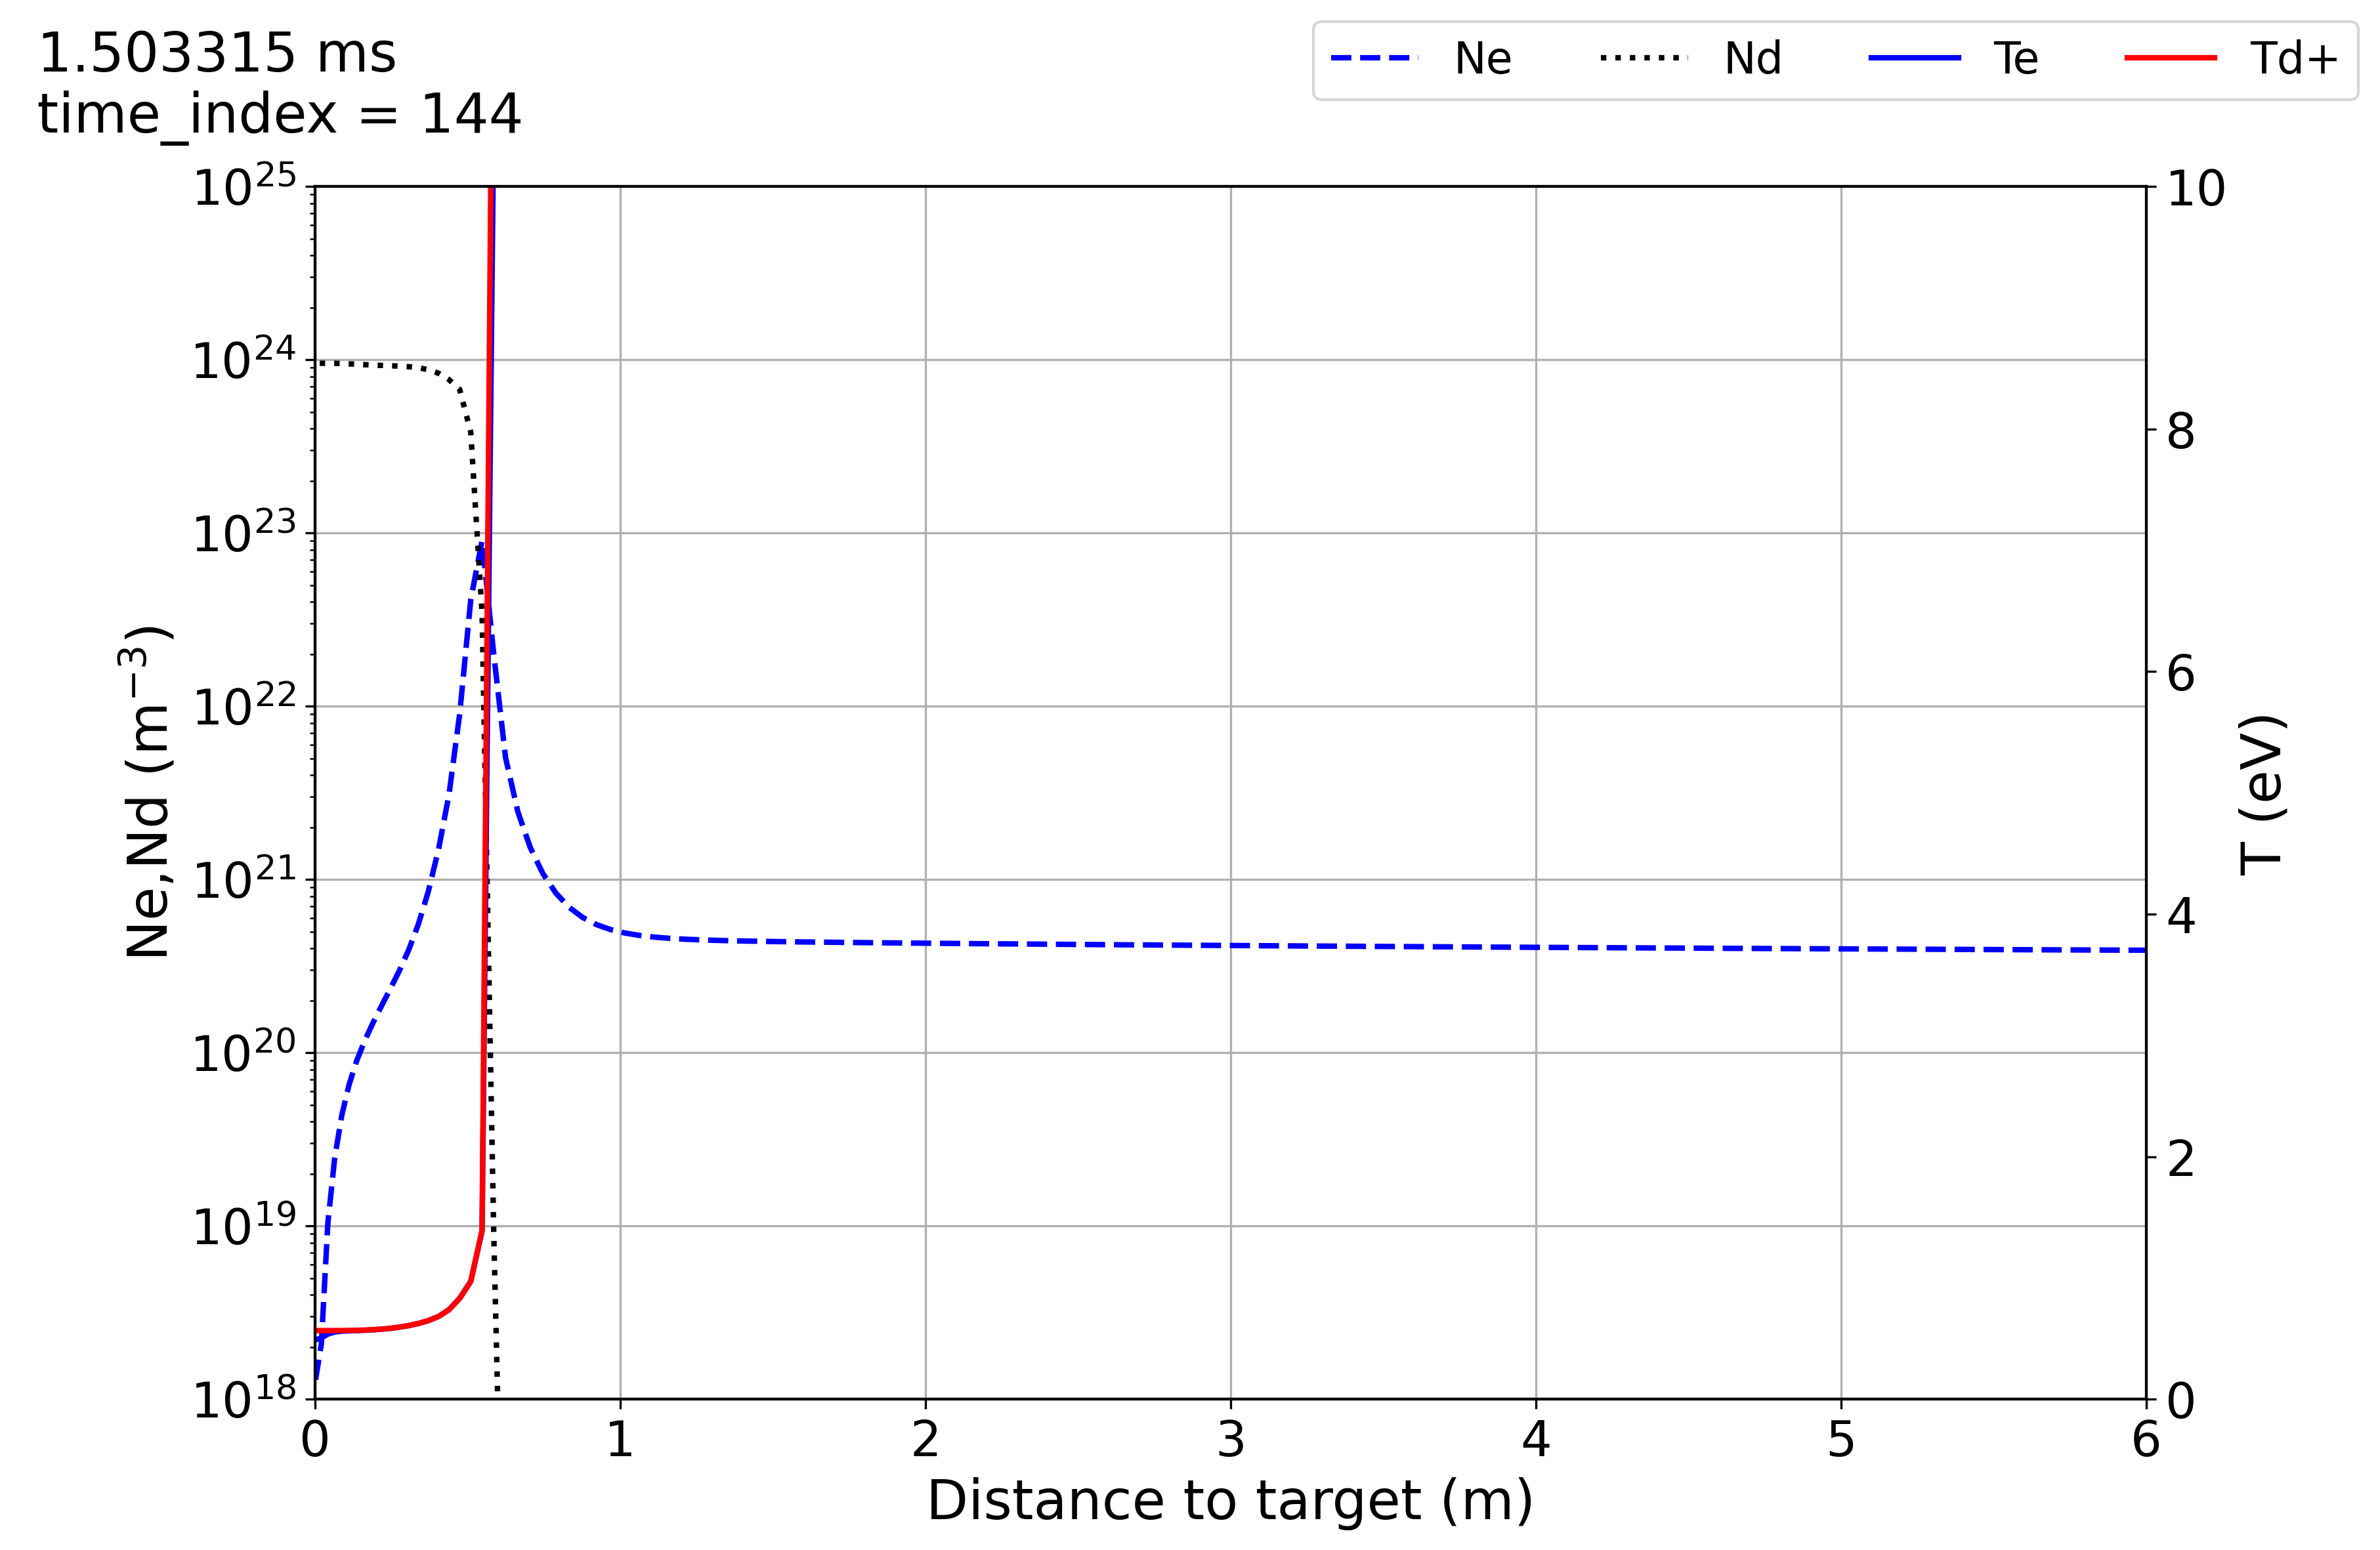

In [ ]:
for i in cs.keys():
    print(f"Making video for {i}")
    make_profile_evolution_video(cs[i], start_time=48, end_time=200, fps=2, mp4_filename=f"{i}_linear_scale_focus_target.mp4", x_log_scale=False, focus_target=True)

make_profile_evolution_video(cs['power_only'], start_time=0, end_time=200, fps=2, mp4_filename="power_only.mp4", x_log_scale=True)


# Spatial particle sources in time 

In [30]:

from PIL import Image

def replace_guards(var):
    """
    Replace the points in the guard cells with boundary values.
    """
    # print(var.values)
    var = np.ravel(var.values)[1:-1]  # Strip the edge guard cells

    var[0] = 0.5 * (var[0] + var[1])
    var[-1] = 0.5 * (var[-1] + var[-2])
    
    return var


import matplotlib.pyplot as plt
from cycler import cycler
def spatial_var(ds_in, time, var=[''], second_axis=[], x_log_scale=True, title='None',
                save=False, save_path=None, focus_target=False, y_scale='log', y_scale2='linear',
                first_profile=None, ylim1=None, ylim2=None):
    fig, ax = plt.subplots(1, 1, figsize=(12, 8), dpi=300)
    linewidth = 2
    ds = ds_in.ds.copy().isel(t=time)

    colors = plt.cm.tab10.colors
    color_cycler = cycler(color=colors)
    ax.set_prop_cycle(color_cycler)

    y = ds['y'][1:-1].values
    y_flipped = (y.max() - y)

    for idx, i in enumerate(var):
        color = colors[idx % len(colors)]
        if first_profile is not None:
            ax.plot(y_flipped, first_profile[i], linestyle='--', linewidth=linewidth,
                    alpha=0.5, color=color)
        ax.plot(y_flipped, replace_guards(ds[i]), label=f'{i}', linewidth=linewidth, color=color)

    ax2 = None
    if second_axis:
        ax2 = ax.twinx()
        ax2.set_prop_cycle(cycler(color=colors[len(var):]))
        for idx, j in enumerate(second_axis):
            color = colors[(len(var) + idx) % len(colors)]
            if first_profile is not None:
                ax2.plot(y_flipped, first_profile[j], linestyle='--', linewidth=linewidth,
                         alpha=0.5, color=color)
            ax2.plot(y_flipped, replace_guards(ds[j]), label=f'{j}', linewidth=linewidth, color=color)
        ax2.set_ylabel(f"{ds[second_axis[0]].units}", fontsize=20)
        ax2.set_yscale(y_scale2)
        if ylim2:
            ax2.set_ylim(*ylim2)

    ax.set_xscale('log' if x_log_scale else 'linear')
    if focus_target:
        ax.set_xlim(0, 5)

    ax.set_yscale(y_scale)
    ax.set_xlabel('Distance to target (m)', fontsize=20)
    ax.set_ylabel(f'{ds[var[0]].units}', fontsize=20)

    if ylim1:
        ax.set_ylim(*ylim1)

    handles1, labels1 = ax.get_legend_handles_labels()
    handles2, labels2 = ax2.get_legend_handles_labels() if ax2 else ([], [])
    fig.legend(handles1 + handles2, labels1 + labels2, ncol=4, loc='upper right')

    fig.suptitle(f"{(ds_in.ds['t'].values[time] - ds_in.ds['t'].values[0]) * 1e3 : 6f} ms \n time_index = {time}",
                 fontsize=20, x=0.0, horizontalalignment='left')

    if save:
        plt.savefig(save_path, bbox_inches='tight')
    plt.close()

def spatial_var_mp4(ds_in, start_time, end_time, var=[''], second_axis=[], fps=5,
                    mp4_filename="spatial_var.mp4", x_log_scale=True,
                    focus_target=False, y_scale='log', y_scale2='linear',
                    ylim1=None, ylim2=None):
    output_dir = "./frames"
    os.makedirs(output_dir, exist_ok=True)

    first_ds = ds_in.ds.copy().isel(t=start_time)
    first_profile = {i: replace_guards(first_ds[i]) for i in var + second_axis}

    frame_paths = []
    for t in range(start_time, end_time):
        frame_path = os.path.join(output_dir, f"frame_{t:03d}.png")
        spatial_var(ds_in, time=t, var=var, second_axis=second_axis, save=True,
                    save_path=frame_path, x_log_scale=x_log_scale,
                    y_scale=y_scale, y_scale2=y_scale2,
                    focus_target=focus_target,
                    first_profile=first_profile, ylim1=ylim1, ylim2=ylim2)
        frame_paths.append(frame_path)

    first_frame = imageio.imread(frame_paths[0])
    target_size = (first_frame.shape[1], first_frame.shape[0])

    writer = imageio.get_writer(mp4_filename, fps=fps, codec='libx264', format='ffmpeg')
    for path in frame_paths:
        frame = imageio.imread(path)
        if (frame.shape[1], frame.shape[0]) != target_size:
            frame = np.array(Image.fromarray(frame).resize(target_size, Image.BICUBIC))
        if frame.shape[2] == 4:
            frame = frame[:, :, :3]
        writer.append_data(frame)
    writer.close()





In [31]:
source_sinks = ['Sd+_iz', 'Sd+_rec', 'Sd+_sheath', 'Sd+_src','Sd_target_recycle','simple_pump_sink_d']
# spatial_var_vs_time(cs['power_only'], time=0, var = source_sinks, x_log_scale=True, save=False, y_scale = 'symlog')



spatial_var_mp4(cs['power_only'], start_time=50, end_time=60, 
                var = ['Nd', 'Pd'],second_axis=['Te', 'Td+' , 'Td'], 
                fps=2, mp4_filename="power_only_neutral_pressure.mp4", 
                x_log_scale=False, focus_target=True, y_scale='log', y_scale2='linear',
                ylim2 = (-2, 10))

IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (3626, 2362) to (3632, 2368) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).
[rawvideo @ 0x5706580] Stream #0: not enough frames to estimate rate; consider increasing probesize
[swscaler @ 0x5725c40] Warning: data is not aligned! This can lead to a speed loss


In [32]:

spatial_var_mp4(cs['power_only'], start_time=50, end_time=60, 
                var = ['NVd'],
                fps=2, mp4_filename="oscillations_2.mp4", 
                x_log_scale=False, focus_target=True, y_scale='linear')

IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (3626, 2362) to (3632, 2368) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).
[rawvideo @ 0x5714580] Stream #0: not enough frames to estimate rate; consider increasing probesize
[swscaler @ 0x5733ac0] Warning: data is not aligned! This can lead to a speed loss


In [33]:
spatial_var_mp4(cs['power_only'], start_time=50, end_time=60, 
                var = ['Pe_src'], 
                fps=2, mp4_filename="pressure_source.mp4", 
                x_log_scale=False, focus_target=False, y_scale='log')

IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (3626, 2362) to (3632, 2368) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).
[rawvideo @ 0x647e580] Stream #0: not enough frames to estimate rate; consider increasing probesize
[swscaler @ 0x649dac0] Warning: data is not aligned! This can lead to a speed loss


# Spatial energy losses in time

# Analysis of new case burnthrough energy

In [34]:
import numpy as np

def detachment_cloud(ds, time_index = 0, verbose = False):
    neutrals = ds['Nd'].isel(t=time_index).values
    cloud_indx = np.where(neutrals > 1e19)[0][0]

    neutral_cloud = neutrals[cloud_indx:-2]
    volume = ds['dv'].values[cloud_indx:-2]

    neutral_number = np.sum(neutral_cloud * volume)

    if verbose:
        print(f'Detachment cloud neutral density: {neutral_cloud[-5]}', r'$m^{-3}$')
        print(f"Detachment cloud neutral number: {neutral_number} #")
        
    return neutral_number

print('before pulse')
detachment_cloud(cs['power_only'].ds, time_index=0,verbose=True)

print('peak pulse')
detachment_cloud(cs['power_only'].ds, time_index=100, verbose=True)


before pulse
Detachment cloud neutral density: 8.782394080521406e+22 $m^{-3}$
Detachment cloud neutral number: 2.579862250025524e+24 #
peak pulse
Detachment cloud neutral density: 1.3742667473755998e+24 $m^{-3}$
Detachment cloud neutral number: 2.738391173906083e+24 #


2.738391173906083e+24

In [35]:
source_sinks = ['Rneon', 'Rd+_rec', 'Rd+_ex']

spatial_var_mp4(cs['power_only'], start_time=50, end_time=200, var = source_sinks, fps=2, mp4_filename="power_only_energy_source_sinks_2.mp4", 
                x_log_scale=True, focus_target=False, y_scale='symlog')

IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (3626, 2362) to (3632, 2368) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).
[rawvideo @ 0x598f580] Stream #0: not enough frames to estimate rate; consider increasing probesize
[swscaler @ 0x59aec40] Warning: data is not aligned! This can lead to a speed loss


# Plot ionisation cross section and temperature

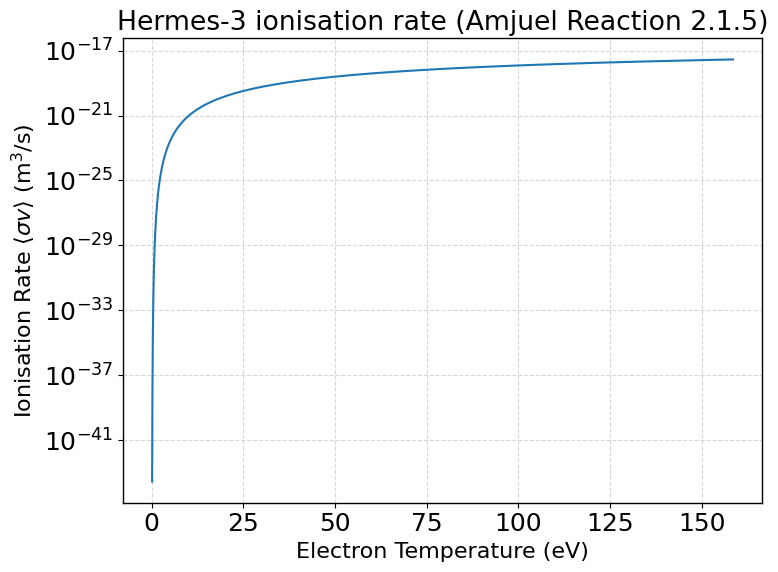

In [36]:
import numpy as np
import matplotlib.pyplot as plt

# Coefficients from Amjuel reaction 2.1.5
rate_coefs = np.array([
    [-32.4802533034, -0.05440669186583, 0.09048888225109, -0.04054078993576, 0.008976513750477, -0.001060334011186, 6.846238436472e-05, -2.242955329604e-06, 2.890437688072e-08],
    [14.2533239151, -0.0359434716076, -0.02014729121556, 0.0103977361573, -0.001771792153042, 0.0001237467264294, -3.130184159149e-06, -3.051994601527e-08, 1.888148175469e-09],
    [-6.632235026785, 0.09255558353174, -0.005580210154625, -0.005902218748238, 0.001295609806553, -0.0001056721622588, 4.646310029498e-06, -1.479612391848e-07, 2.85225125832e-09],
    [2.059544135448, -0.07562462086943, 0.01519595967433, 0.0005803498098354, -0.0003527285012725, 3.201533740322e-05, -1.835196889733e-06, 9.474014343303e-08, -2.342505583774e-09],
    [-0.442537033141, 0.02882634019199, -0.00728577148505, 0.0004643389885987, 1.145700685235e-06, 8.493662724988e-07, -1.001032516512e-08, -1.476839184318e-08, 6.047700368169e-10],
    [0.06309381861496, -0.00578868653578, 0.00150738295525, -0.0001201550548662, 6.574487543511e-06, -9.678782818849e-07, 5.176265845225e-08, 1.29155167686e-09, -9.685157340473e-11],
    [-0.005620091829261, 0.000632910556804, -0.0001527777697951, 8.270124691336e-06, 3.224101773605e-08, 4.377402649057e-08, -2.622921686955e-09, -2.259663431436e-10, 1.161438990709e-11],
    [0.0002812016578355, -3.564132950345e-05, 7.222726811078e-06, 1.433018694347e-07, -1.097431215601e-07, 7.789031791949e-09, -4.197728680251e-10, 3.032260338723e-11, -8.911076930014e-13],
    [-6.011143453374e-06, 8.089651265488e-07, -1.186212683668e-07, -2.381080756307e-08, 6.271173694534e-09, -5.48301024493e-10, 3.064611702159e-11, -1.355903284487e-12, 2.935080031599e-14]
])

def ionisation_rate(logTe, logne):
    """Evaluate the ionisation rate <σv> from log10(Te), log10(ne) using the Amjuel coefficients"""
    rate = 0.0
    for i in range(9):
        for j in range(9):
            rate += rate_coefs[i][j] * logTe**i * logne**j
    return 10 ** rate  # Convert from log10(rate) to rate

# Temperature range (eV)
Te = np.logspace(-1, 2.2, 300)  # 0.1 to ~160 eV
logTe = np.log10(Te)

# Fixed density: 1e19 m^-3
logne = np.log10(1e20)

# Compute rate
rates = np.array([ionisation_rate(lt, logne) for lt in logTe])

# Plot
plt.figure(figsize=(8, 6))
plt.plot(Te, rates)
# plt.xscale('log')
# plt.xlim(0, 2)
plt.yscale('log')
plt.xlabel('Electron Temperature (eV)')
plt.ylabel(r'Ionisation Rate $\langle \sigma v \rangle$ (m$^3$/s)')
plt.title('Hermes-3 ionisation rate (Amjuel Reaction 2.1.5)')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


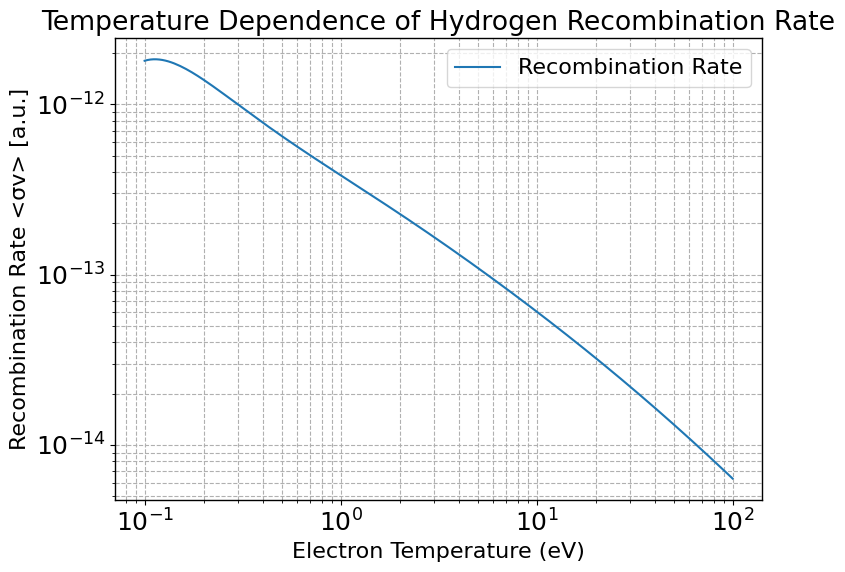

In [37]:
import numpy as np
import matplotlib.pyplot as plt

# Define the recombination rate coefficients from the user-provided code
recombination_rate_coefs = np.array([
    [-28.58858570847, 0.02068671746773, -0.007868331504755, 0.003843362133859,
     -0.0007411492158905, 9.273687892997e-05, -7.063529824805e-06, 3.026539277057e-07,
     -5.373940838104e-09],
    [-0.7676413320499, 0.0127800603259, -0.01870326896978, 0.00382855504889,
     -0.0003627770385335, 4.401007253801e-07, 1.932701779173e-06, -1.176872895577e-07,
     2.215851843121e-09],
    [0.002823851790251, -0.001907812518731, 0.01121251125171, -0.003711328186517,
     0.0006617485083301, -6.860774445002e-05, 4.508046989099e-06, -1.723423509284e-07,
     2.805361431741e-09],
    [-0.01062884273731, -0.01010719783828, 0.004208412930611, -0.00100574441054,
     0.0001013652422369, -2.044691594727e-06, -4.431181498017e-07, 3.457903389784e-08,
     -7.374639775683e-10],
    [0.001582701550903, 0.002794099401979, -0.002024796037098, 0.0006250304936976,
     -9.224891301052e-05, 7.546853961575e-06, -3.682709551169e-07, 1.035928615391e-08,
     -1.325312585168e-10],
    [-0.0001938012790522, 0.0002148453735781, 3.393285358049e-05, -3.746423753955e-05,
     7.509176112468e-06, -8.688365258514e-07, 7.144767938783e-08, -3.367897014044e-09,
     6.250111099227e-11],
    [6.041794354114e-06, -0.0001421502819671, 6.14387907608e-05, -1.232549226121e-05,
     1.394562183496e-06, -6.434833988001e-08, -2.746804724917e-09, 3.564291012995e-10,
     -8.55170819761e-12],
    [1.742316850715e-06, 1.595051038326e-05, -7.858419208668e-06, 1.774935420144e-06,
     -2.187584251561e-07, 1.327090702659e-08, -1.386720240985e-10, -1.946206688519e-11,
     5.745422385081e-13],
    [-1.384927774988e-07, -5.664673433879e-07, 2.886857762387e-07, -6.591743182569e-08,
     8.008790343319e-09, -4.805837071646e-10, 6.459706573699e-12, 5.510729582791e-13,
     -1.680871303639e-14]
])

# Temperature range in eV
Te = np.logspace(-1, 2, 200)  # 0.1 eV to 100 eV
lnTe = np.log(Te)

# Fit to a polynomial in lnTe and evaluate
rate = np.zeros_like(Te)
for i in range(9):
    for j in range(9):
        rate += recombination_rate_coefs[i][j] * lnTe**i * lnTe**j

# Plot the recombination rate as a function of temperature
plt.figure(figsize=(8, 6))
plt.plot(Te, np.exp(rate), label="Recombination Rate")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Electron Temperature (eV)")
plt.ylabel("Recombination Rate <σv> [a.u.]")
plt.title("Temperature Dependence of Hydrogen Recombination Rate")
plt.grid(True, which="both", ls="--")
plt.legend()
plt.tight_layout()
plt.show()


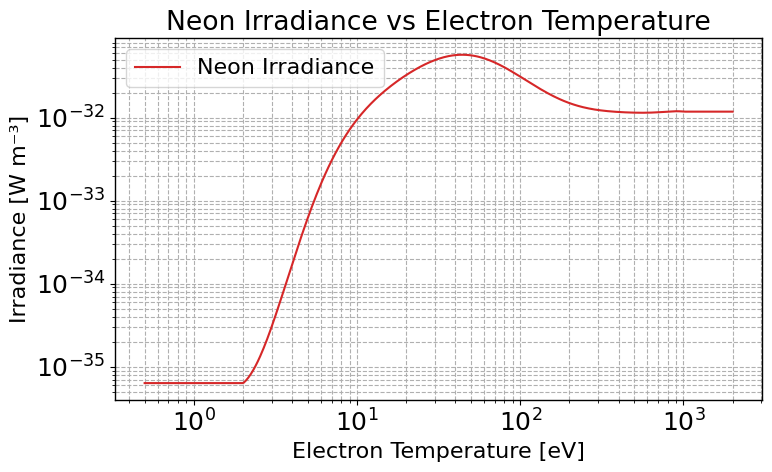

In [38]:
import numpy as np
import matplotlib.pyplot as plt

# Define the temperature range for valid neon irradiance values (2 to 1000 eV)
Te = np.logspace(np.log10(0.5), np.log10(2000), 500)
logT = np.log(Te)

# Initialize output array
irradiance = np.zeros_like(Te)

# Apply the piecewise definition
for i, T in enumerate(Te):
    if T < 2:
        irradiance[i] = 6.35304113e-36
    elif T > 1000:
        irradiance[i] = 1.17894628e-32
    else:
        log_out = (
            -8.21475117e+01 * logT[i]**0
            +1.28929854e+01 * logT[i]**1
            -4.74266289e+01 * logT[i]**2
            +7.45222324e+01 * logT[i]**3
            -5.75710722e+01 * logT[i]**4
            +2.57375965e+01 * logT[i]**5
            -7.12758563e+00 * logT[i]**6
            +1.24287546e+00 * logT[i]**7
            -1.32943407e-01 * logT[i]**8
            +7.97368445e-03 * logT[i]**9
            -2.05487897e-04 * logT[i]**10
        )
        irradiance[i] = np.exp(log_out)

# Plotting
plt.figure(figsize=(8, 5))
plt.loglog(Te, irradiance, label='Neon Irradiance', color='tab:red')
plt.xlabel('Electron Temperature [eV]')
plt.ylabel('Irradiance [W m⁻³]')
plt.title('Neon Irradiance vs Electron Temperature')
plt.grid(True, which='both', ls='--')
plt.legend()
plt.tight_layout()
plt.show()
